# YOLO + ST-GCN — Experiment Notebook

Runs all four experiments in sequence:

| # | Experiment | Purpose |
|---|---|---|
| 1 | Re-train with official split | Honest baseline — removes data leakage from old random split |
| 2 | Multi-person diagnostic | Quantify YOLO multi-detection noise for the report |
| 3 | Pipeline eval (YOLO + IoU tracking + ST-GCN) | End-to-end accuracy on official test set |
| 4 | Results summary | Print comparison table and decide Branch 3A vs 3B |

**Requirements**: Google Drive mount with `stgcn_penn_action.pth` (for Exp 3 if skipping Exp 1),  
or run Exp 1 first to produce fresh weights.

## Setup

In [1]:
import subprocess, sys, os, zipfile

# Install dependencies
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'ultralytics', 'gdown', 'tqdm', '-q'], check=True)

# Clone repo (skip if already present)
if not os.path.exists('/content/Yolo-ST-GCN'):
    subprocess.run(['git', 'clone', 'https://github.com/schizocatto/Yolo-ST-GCN.git',
                    '/content/Yolo-ST-GCN'], check=True)
else:
    subprocess.run(['git', '-C', '/content/Yolo-ST-GCN', 'pull'], check=True)

os.chdir('/content/Yolo-ST-GCN')
sys.path.insert(0, '/content/Yolo-ST-GCN')
print('Repo ready:', os.getcwd())

Repo ready: /content/Yolo-ST-GCN


In [2]:
# Download Penn Action dataset from Google Drive
import gdown

DATASET_GD_ID  = '15SLfJN2pa-UsvILdaOVH0CuhbS-Zd2yk'
DOWNLOAD_DIR   = '/content/penn_action'
DATA_DIR       = os.path.join(DOWNLOAD_DIR, 'Penn_Action')
LABELS_DIR     = os.path.join(DATA_DIR, 'labels')
FRAMES_DIR     = os.path.join(DATA_DIR, 'frames')

if os.path.exists(DATA_DIR):
    print('Dataset already present — skipping download.')
else:
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    zip_path = os.path.join(DOWNLOAD_DIR, 'penn-action.zip')
    gdown.download(id=DATASET_GD_ID, output=zip_path, quiet=False)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DOWNLOAD_DIR)
    os.remove(zip_path)

print(f'Labels dir : {os.path.exists(LABELS_DIR)}')
print(f'Frames dir : {os.path.exists(FRAMES_DIR)}')

Downloading...
From (original): https://drive.google.com/uc?id=15SLfJN2pa-UsvILdaOVH0CuhbS-Zd2yk
From (redirected): https://drive.google.com/uc?id=15SLfJN2pa-UsvILdaOVH0CuhbS-Zd2yk&confirm=t&uuid=a0bb71f4-cf66-4b98-b1e0-550764e8e0a5
To: /content/penn_action/penn-action.zip
100%|██████████| 3.44G/3.44G [00:36<00:00, 94.6MB/s]


Labels dir : True
Frames dir : True


In [3]:
# Core imports
import glob, json
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report

from src.config import EXERCISE_CLASSES, CLASS_TO_ID
from src.dataset import build_data_tensors, PennActionDataset
from src.model import Model_STGCN
from src.train import train_model, eval_epoch
from src.inference import extract_yolo_keypoints, run_stgcn_inference, load_stgcn_weights
from src.visualize import (
    plot_training_curves, plot_confusion_matrix,
    plot_per_class_f1, plot_keypoint_quality
)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT_DIR  = '/content/Yolo-ST-GCN/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# Shared results dict — populated by each experiment
RESULTS = {}

print(f'Device  : {DEVICE}')
print(f'Classes : {EXERCISE_CLASSES}')

Device  : cuda
Classes : ['bench_press', 'clean_and_jerk', 'jump_rope', 'jumping_jacks', 'pullup', 'pushup', 'situp', 'squat']


---
## Experiment 1 — Re-train ST-GCN with Official Split

**Goal:** Establish an honest baseline by training on the official Penn Action subject-isolated
train partition and evaluating on the official test partition.  
The old notebooks used a random 80/20 split which allowed the same person to appear in both
train and val (data leakage).  

Expected: accuracy may drop vs. old reported numbers — that is the correct result.

In [4]:
from torch.utils.data import DataLoader

# ── Load & split by official flag ─────────────────────────────────────
print('Loading data...')
data, labels, flags, _, video_ids = build_data_tensors(LABELS_DIR)
print(f'  Total  : {len(data)}')
print(f'  Train  : {(flags==1).sum()}  (official train flag=1)')
print(f'  Test   : {(flags==0).sum()}  (official test  flag=0)')

# Build test file list from the SAME split — shared across all experiments
test_vid_set = {vid for vid, f in zip(video_ids, flags) if f == 0}
mat_test, lbl_test = [], []
for mf in sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat'))):
    vid_id = os.path.splitext(os.path.basename(mf))[0]
    if vid_id not in test_vid_set:
        continue
    md = scipy.io.loadmat(mf)
    action = str(md['action'][0][0] if isinstance(md['action'][0], np.ndarray) else md['action'][0])
    if action in CLASS_TO_ID:
        mat_test.append(mf)
        lbl_test.append(CLASS_TO_ID[action])
print(f'  Test files for pipeline eval: {len(mat_test)}')

X_train, y_train = data[flags==1], labels[flags==1]
X_test,  y_test  = data[flags==0], labels[flags==0]

BATCH_SIZE = 32
train_loader = DataLoader(PennActionDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(PennActionDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

Loading data...
[dataset] No official test split found — applying per-class subject-isolated split (last 30% per class = test).
  Total  : 1163
  Train  : 814  (official train flag=1)
  Test   : 349  (official test  flag=0)


In [5]:
# ── Train ─────────────────────────────────────────────────────────────
NUM_EPOCHS = 50

model_gt = Model_STGCN(num_classes=8).to(DEVICE)

history = train_model(
    model_gt, train_loader, test_loader,
    num_epochs=NUM_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
)

WEIGHTS_PATH = os.path.join(OUT_DIR, 'stgcn_official_split.pth')
torch.save(model_gt.state_dict(), WEIGHTS_PATH)
print(f'Weights saved to {WEIGHTS_PATH}')

/content/Yolo-ST-GCN/src/graph.py:68: RuntimeWarning: divide by zero encountered in divide
  D_inv   = np.where(row_sum > 0, 1.0 / row_sum, 0.0)


Epoch 1/50  train_loss=2.0167  train_acc=0.2260  val_loss=1.8136  val_acc=0.3610  val_f1=0.1758
Epoch 2/50  train_loss=1.7702  train_acc=0.3329  val_loss=1.7568  val_acc=0.3840  val_f1=0.2258
Epoch 3/50  train_loss=1.6910  train_acc=0.3759  val_loss=1.5561  val_acc=0.4756  val_f1=0.2506
Epoch 4/50  train_loss=1.5161  train_acc=0.4447  val_loss=1.2723  val_acc=0.6017  val_f1=0.4787
Epoch 5/50  train_loss=1.3220  train_acc=0.5307  val_loss=0.9734  val_acc=0.6447  val_f1=0.5454
Epoch 6/50  train_loss=1.1229  train_acc=0.6093  val_loss=0.9907  val_acc=0.6905  val_f1=0.5859
Epoch 7/50  train_loss=0.9950  train_acc=0.6462  val_loss=0.7347  val_acc=0.7479  val_f1=0.7126
Epoch 8/50  train_loss=0.6363  train_acc=0.7973  val_loss=0.5209  val_acc=0.8281  val_f1=0.8405
Epoch 9/50  train_loss=0.9143  train_acc=0.7396  val_loss=0.7283  val_acc=0.7278  val_f1=0.7357
Epoch 10/50  train_loss=0.6154  train_acc=0.8219  val_loss=0.4433  val_acc=0.9054  val_f1=0.9070
Epoch 11/50  train_loss=0.3536  train_a


=== Experiment 1 Results (GT skeleton, official split) ===
Accuracy  : 0.9628
Macro F1  : 0.9629

--- Classification Report ---
                precision    recall  f1-score   support

   bench_press       0.89      1.00      0.94        42
clean_and_jerk       1.00      1.00      1.00        26
     jump_rope       0.96      0.96      0.96        25
 jumping_jacks       1.00      0.97      0.99        34
        pullup       0.95      0.95      0.95        60
        pushup       0.98      0.97      0.98        63
         situp       0.90      0.93      0.92        30
         squat       1.00      0.94      0.97        69

      accuracy                           0.96       349
     macro avg       0.96      0.97      0.96       349
  weighted avg       0.96      0.96      0.96       349

  saved /content/Yolo-ST-GCN/outputs/exp1_training_curves.png
  saved /content/Yolo-ST-GCN/outputs/exp1_confusion_matrix.png
  saved /content/Yolo-ST-GCN/outputs/exp1_per_class_f1.png


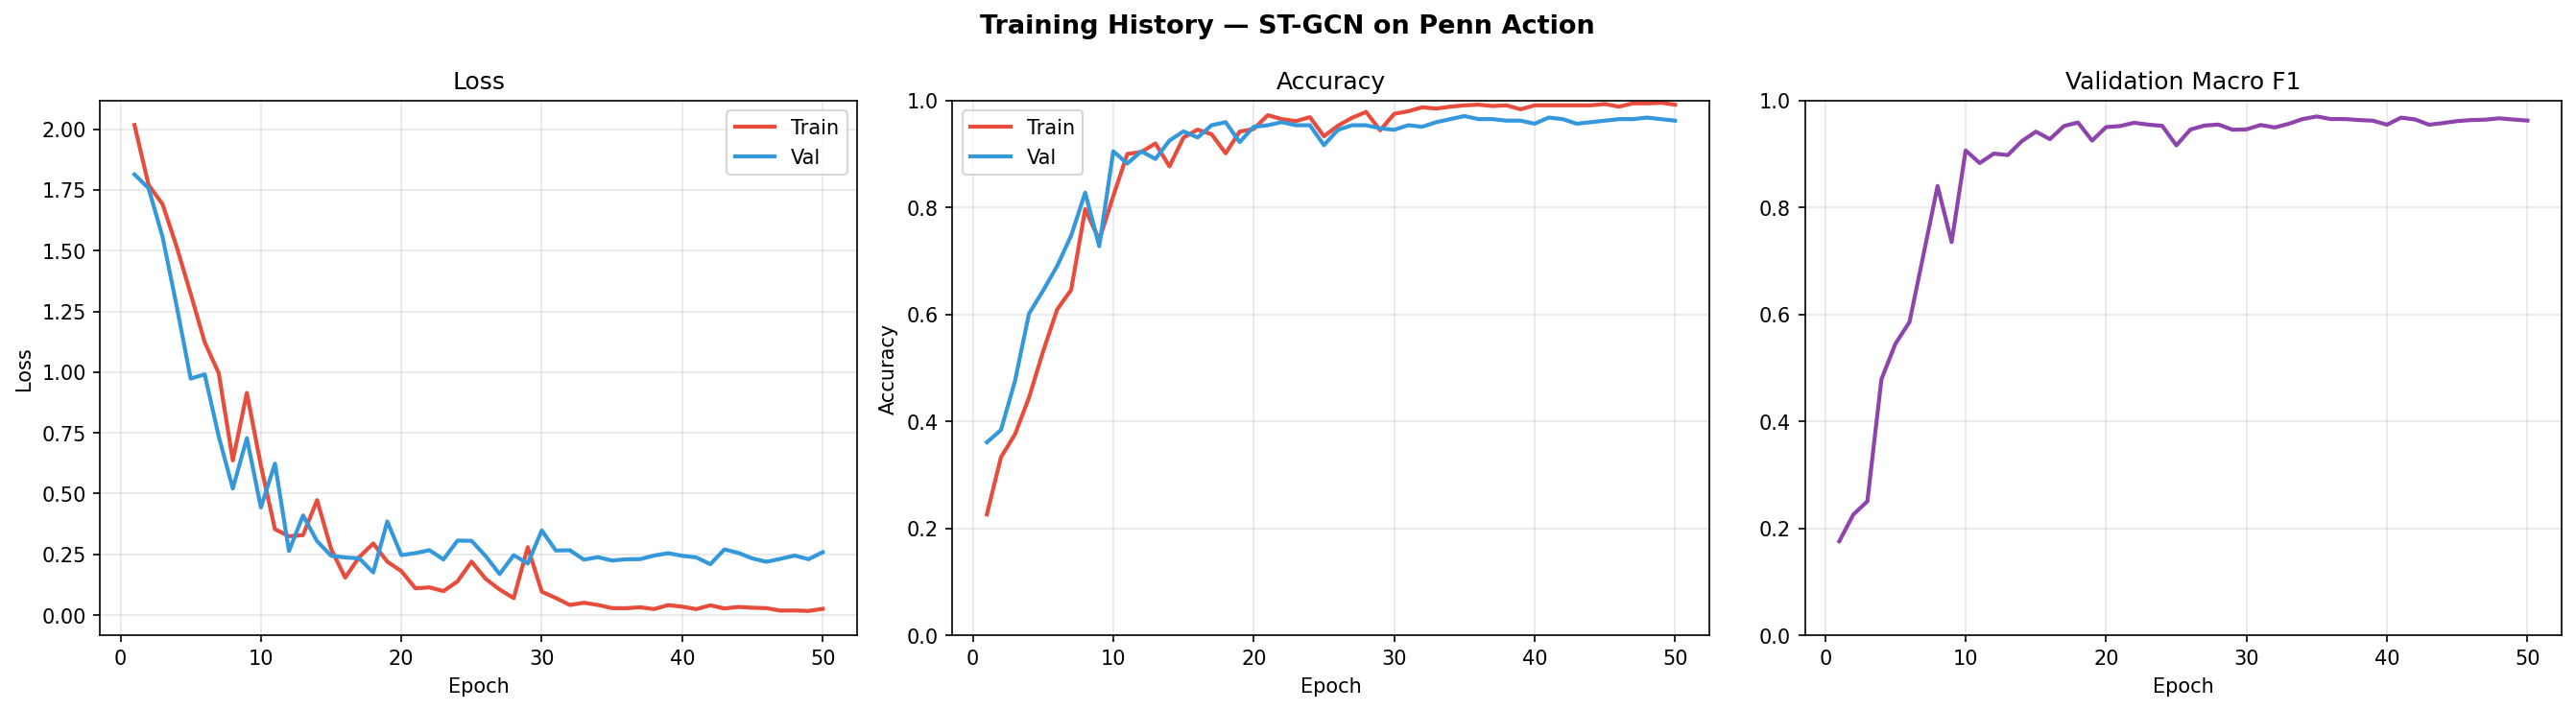

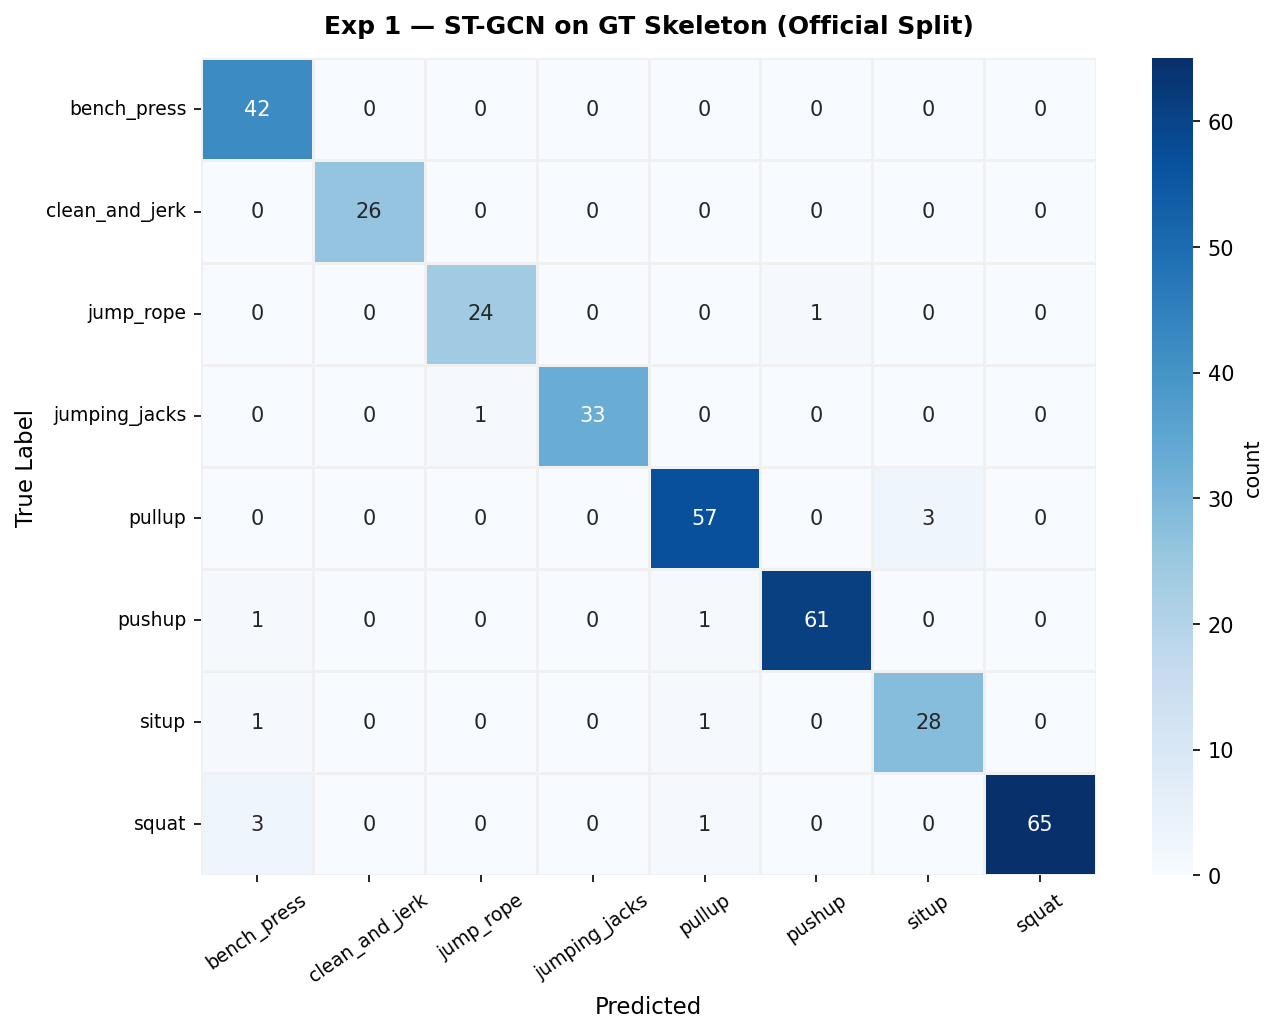

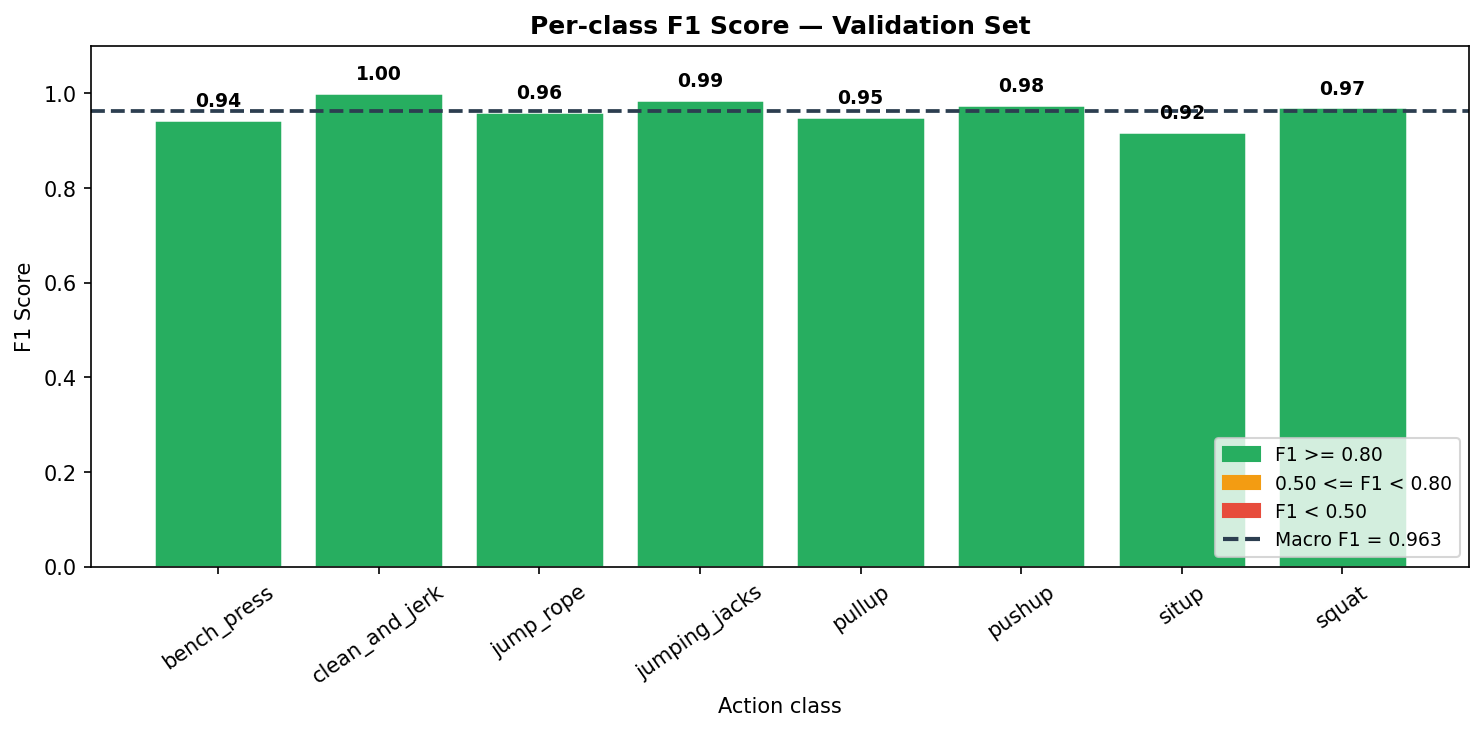

In [6]:
# ── Evaluate on official test set ──────────────────────────────────────
import torch.nn as nn

_, gt_acc, gt_f1, gt_preds, gt_labels = eval_epoch(
    model_gt, test_loader, nn.CrossEntropyLoss(), DEVICE
)

RESULTS['exp1_gt_acc'] = gt_acc
RESULTS['exp1_gt_f1']  = gt_f1

print(f'\n=== Experiment 1 Results (GT skeleton, official split) ===')
print(f'Accuracy  : {gt_acc:.4f}')
print(f'Macro F1  : {gt_f1:.4f}')
print('\n--- Classification Report ---')
print(classification_report(gt_labels, gt_preds,
                             target_names=EXERCISE_CLASSES, zero_division=0))

# Plots
plot_training_curves(history,         out_dir=OUT_DIR, filename='exp1_training_curves.png')
plot_confusion_matrix(gt_labels, gt_preds,
                      title='Exp 1 — ST-GCN on GT Skeleton (Official Split)',
                      out_dir=OUT_DIR, filename='exp1_confusion_matrix.png')
plot_per_class_f1(gt_labels, gt_preds, out_dir=OUT_DIR, filename='exp1_per_class_f1.png')

# Show plots inline
for fname in ['exp1_training_curves.png', 'exp1_confusion_matrix.png', 'exp1_per_class_f1.png']:
    from IPython.display import display, Image
    display(Image(os.path.join(OUT_DIR, fname)))

---
## Experiment 2 — Multi-person Diagnostic

**Goal:** Count exactly how many videos and frames have ≥2 YOLO detections per action class.  
This quantifies the multi-person noise problem and provides numbers for the report.

In [7]:
import scipy.io
from ultralytics import YOLO

model_yolo = YOLO('yolov8n-pose.pt')
print('YOLOv8-pose loaded.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8-pose loaded.


In [8]:
stats = defaultdict(lambda: {
    'total_videos': 0, 'videos_with_multiperson': 0,
    'total_frames': 0, 'frames_with_multiperson': 0,
})

mat_files = sorted(glob.glob(os.path.join(LABELS_DIR, '*.mat')))

for mat_path in tqdm(mat_files, desc='Exp 2 — Multi-person scan'):
    md = scipy.io.loadmat(mat_path)
    action = str(md['action'][0][0] if isinstance(md['action'][0], np.ndarray) else md['action'][0])
    if action not in EXERCISE_CLASSES:
        continue

    vid_id      = os.path.splitext(os.path.basename(mat_path))[0]
    frame_paths = sorted(glob.glob(os.path.join(FRAMES_DIR, vid_id, '*.jpg')))
    if not frame_paths:
        continue

    s = stats[action]
    s['total_videos'] += 1
    video_has_mp = False

    for fp in frame_paths:
        res  = model_yolo(fp, verbose=False)
        n    = len(res[0].boxes) if res[0].boxes is not None else 0
        s['total_frames'] += 1
        if n >= 2:
            s['frames_with_multiperson'] += 1
            video_has_mp = True
    if video_has_mp:
        s['videos_with_multiperson'] += 1

# ── Print summary ─────────────────────────────────────────────────────
print('\n=== Experiment 2 — Multi-person Detection Summary ===\n')
print(f'{"Action":<22} {"Videos (≥2 ppl)":<20} {"Frames (≥2 ppl)"}')
print('-' * 65)

tot_v = tot_vmp = tot_f = tot_fmp = 0
for action in EXERCISE_CLASSES:
    s = stats[action]
    v_pct = 100 * s['videos_with_multiperson'] / max(s['total_videos'], 1)
    f_pct = 100 * s['frames_with_multiperson'] / max(s['total_frames'], 1)
    print(f'{action:<22} {s["videos_with_multiperson"]}/{s["total_videos"]} ({v_pct:.1f}%)'
          f'          {s["frames_with_multiperson"]}/{s["total_frames"]} ({f_pct:.1f}%)')
    tot_v += s['total_videos'];  tot_vmp += s['videos_with_multiperson']
    tot_f += s['total_frames'];  tot_fmp += s['frames_with_multiperson']

print('-' * 65)
print(f'{"TOTAL":<22} {tot_vmp}/{tot_v} ({100*tot_vmp/max(tot_v,1):.1f}%)'
      f'          {tot_fmp}/{tot_f} ({100*tot_fmp/max(tot_f,1):.1f}%)')

RESULTS['exp2_multiperson'] = {
    'per_class': {k: dict(v) for k, v in stats.items()},
    'overall': {'total_videos': tot_v, 'videos_with_multiperson': tot_vmp,
                'total_frames': tot_f, 'frames_with_multiperson': tot_fmp},
}

with open(os.path.join(OUT_DIR, 'multiperson_stats.json'), 'w') as f:
    json.dump(RESULTS['exp2_multiperson'], f, indent=2)
print(f'\nSaved multiperson_stats.json')

Exp 2 — Multi-person scan:   0%|          | 0/2326 [00:00<?, ?it/s]


=== Experiment 2 — Multi-person Detection Summary ===

Action                 Videos (≥2 ppl)      Frames (≥2 ppl)
-----------------------------------------------------------------
bench_press            122/140 (87.1%)          6006/11576 (51.9%)
clean_and_jerk         66/88 (75.0%)          8893/23862 (37.3%)
jump_rope              35/82 (42.7%)          374/3642 (10.3%)
jumping_jacks          47/112 (42.0%)          501/3362 (14.9%)
pullup                 85/199 (42.7%)          2923/13865 (21.1%)
pushup                 141/211 (66.8%)          3658/10513 (34.8%)
situp                  55/100 (55.0%)          2391/8763 (27.3%)
squat                  155/231 (67.1%)          7052/21351 (33.0%)
-----------------------------------------------------------------
TOTAL                  706/1163 (60.7%)          31798/96934 (32.8%)

Saved multiperson_stats.json


---
## Experiment 3 — Full Pipeline Eval (YOLO + IoU Tracking + ST-GCN)

**Goal:** Run the end-to-end pipeline on the official test set using the weights from Exp 1.  
Single-person selection + IoU tracking is applied in `extract_yolo_keypoints()`.  
Compare against Exp 1 (GT skeleton) to quantify the YOLO extraction gap.

In [9]:
# Load ST-GCN weights produced by Exp 1
# (Change WEIGHTS_PATH if using a pre-existing checkpoint)
model_pipeline = load_stgcn_weights(
    Model_STGCN(num_classes=8).to(DEVICE),
    WEIGHTS_PATH,
    DEVICE,
)
print(f'Loaded weights from {WEIGHTS_PATH}')

Loaded weights from /content/Yolo-ST-GCN/outputs/stgcn_official_split.pth


/content/Yolo-ST-GCN/src/graph.py:68: RuntimeWarning: divide by zero encountered in divide
  D_inv   = np.where(row_sum > 0, 1.0 / row_sum, 0.0)


In [10]:
# mat_test and lbl_test are built in the data loading cell above
print(f'Official test set: {len(mat_test)} videos')

In [ ]:
all_preds, all_gt, n_failed = [], [], 0

for mat_file, gt_label in tqdm(zip(mat_test, lbl_test),
                                total=len(mat_test), desc='Exp 3 — Pipeline eval'):
    vid_id = os.path.splitext(os.path.basename(mat_file))[0]
    kpts_aligned, _ = extract_yolo_keypoints(FRAMES_DIR, vid_id, model_yolo)
    if kpts_aligned is None:
        n_failed += 1
        continue
    pred_idx, _ = run_stgcn_inference(kpts_aligned, model_pipeline, DEVICE)
    all_preds.append(pred_idx)
    all_gt.append(gt_label)

pipe_acc = accuracy_score(all_gt, all_preds)
pipe_f1  = f1_score(all_gt, all_preds, average='macro', zero_division=0)

RESULTS['exp3_pipe_acc'] = pipe_acc
RESULTS['exp3_pipe_f1']  = pipe_f1

print(f'\n=== Experiment 3 Results (YOLO + IoU tracking + ST-GCN) ===')
print(f'Evaluated : {len(all_preds)}  |  Skipped (no frames): {n_failed}')
print(f'Accuracy  : {pipe_acc:.4f}')
print(f'Macro F1  : {pipe_f1:.4f}')
print('\n--- Classification Report ---')
print(classification_report(all_gt, all_preds,
                             target_names=EXERCISE_CLASSES, zero_division=0))

plot_confusion_matrix(all_gt, all_preds,
                      title='Exp 3 — YOLO + IoU Tracking + ST-GCN (Official Test)',
                      out_dir=OUT_DIR, filename='exp3_confusion_matrix.png')
plot_per_class_f1(all_gt, all_preds, out_dir=OUT_DIR, filename='exp3_per_class_f1.png')

for fname in ['exp3_confusion_matrix.png', 'exp3_per_class_f1.png']:
    from IPython.display import display, Image
    display(Image(os.path.join(OUT_DIR, fname)))

Exp 3 — Pipeline eval: 0it [00:00, ?it/s]


=== Experiment 3 Results (YOLO + IoU tracking + ST-GCN) ===
Evaluated : 0  |  Skipped (no frames): 0
Accuracy  : nan
Macro F1  : nan

--- Classification Report ---


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: Number of classes, 0, does not match size of target_names, 8. Try specifying the labels parameter

---
## Experiment 4 — Results Summary & Decision

Compare GT skeleton baseline (Exp 1) vs full pipeline (Exp 3) and decide the next branch.

In [ ]:
gt_acc   = RESULTS['exp1_gt_acc']
gt_f1    = RESULTS['exp1_gt_f1']
pipe_acc = RESULTS['exp3_pipe_acc']
pipe_f1  = RESULTS['exp3_pipe_f1']
mp       = RESULTS['exp2_multiperson']['overall']

print('=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f'\nExp 1 — GT skeleton  (official split, no leakage)')
print(f'  Accuracy  : {gt_acc:.4f}')
print(f'  Macro F1  : {gt_f1:.4f}')
print(f'\nExp 2 — Multi-person noise')
print(f'  Videos with ≥2 detections : {mp["videos_with_multiperson"]}/{mp["total_videos"]} '
      f'({100*mp["videos_with_multiperson"]/max(mp["total_videos"],1):.1f}%)')
print(f'  Frames with ≥2 detections : {mp["frames_with_multiperson"]}/{mp["total_frames"]} '
      f'({100*mp["frames_with_multiperson"]/max(mp["total_frames"],1):.1f}%)')
print(f'\nExp 3 — Full pipeline (YOLO + IoU tracking + ST-GCN)')
print(f'  Accuracy  : {pipe_acc:.4f}  (Δ vs Exp1: {pipe_acc - gt_acc:+.4f})')
print(f'  Macro F1  : {pipe_f1:.4f}  (Δ vs Exp1: {pipe_f1 - gt_f1:+.4f})')

print('\n' + '=' * 60)
print('DECISION')
print('=' * 60)
delta_f1 = pipe_f1 - gt_f1
if delta_f1 >= -0.05:
    print(f'\nF1 drop = {delta_f1:+.4f} (within -0.05 threshold)')
    print('→ Branch 3A: Fine-tune YOLO on cropped single-person Penn Action frames.')
    print('  Next steps:')
    print('  1. Crop each Penn Action frame to person bounding box')
    print('  2. Convert 13-joint GT coordinates to YOLO label format')
    print('  3. Fine-tune YOLOv8-pose on these crops (focus on low-F1 classes)')
else:
    print(f'\nF1 drop = {delta_f1:+.4f} (exceeds -0.05 threshold)')
    print('→ Branch 3B: Improve ST-GCN robustness to noisy keypoints.')
    print('  Next steps:')
    print('  1. Joint Dropout: randomly zero keypoints during ST-GCN training')
    print('  2. Bone-stream: add edge vectors between joints as a second input channel')

# Save full results
with open(os.path.join(OUT_DIR, 'experiment_results.json'), 'w') as f:
    json.dump(RESULTS, f, indent=2, default=float)
print(f'\nFull results saved to {OUT_DIR}/experiment_results.json')

In [ ]:
# Comparison bar chart: GT vs Pipeline accuracy and F1
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Experiment Results: GT Skeleton vs YOLO Pipeline', fontsize=13, fontweight='bold')

labels  = ['GT Skeleton\n(Exp 1)', 'YOLO Pipeline\n(Exp 3)']
accs    = [gt_acc, pipe_acc]
f1s     = [gt_f1,  pipe_f1]
colors  = ['#2ecc71', '#3498db']

for ax, vals, title in zip(axes, [accs, f1s], ['Accuracy', 'Macro F1']):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2, width=0.4)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'exp_comparison.png'), dpi=150, bbox_inches='tight')

from IPython.display import display, Image
display(Image(os.path.join(OUT_DIR, 'exp_comparison.png')))